# 🌍 Analyse de la qualité de vie par pays

## 🎯 Objectif
Analyser les indicateurs socio-économiques afin de comparer la qualité de vie entre différents pays.

## 🧠 Problématique
Quels pays offrent la meilleure qualité de vie selon les indicateurs disponibles ?

## 📂 Compréhension du dataset

Le dataset contient plusieurs indicateurs socio-économiques pour différents pays.

Variables principales :
- Country : pays
- Indicator : type d’indicateur (revenu, logement, satisfaction…)
- Value : valeur de l’indicateur

In [3]:
#CHARGEMENT
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("oecd_bli_2015.csv")
df.head()

,LOCATION,Country,INDICATOR,Indicator,MEASURE,Measure,INEQUALITY,Inequality,Unit Code,Unit,PowerCode Code,PowerCode,Reference Period Code,Reference Period,Value,Flag Codes,Flags
0,AUS,Australia,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.1,E,Estimated value
1,AUT,Austria,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,1.0,NaN,NaN
2,BEL,Belgium,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,2.0,NaN,NaN
3,CAN,Canada,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.2,NaN,NaN
4,CZE,Czech Republic,HO_BASE,Dwellings without basic facilities,L,Value,TOT,Total,PC,Percentage,0,units,NaN,NaN,0.9,NaN,NaN


In [4]:
df.columns

Index(['LOCATION', 'Country', 'INDICATOR', 'Indicator', 'MEASURE', 'Measure',
       'INEQUALITY', 'Inequality', 'Unit Code', 'Unit', 'PowerCode Code',
       'PowerCode', 'Reference Period Code', 'Reference Period', 'Value',
       'Flag Codes', 'Flags'],
      dtype='object')

In [5]:
#NETTOYAGE
df_clean = df[["Country", "Indicator", "Value"]]
df_clean.isnull().sum()

Country      0
Indicator    0
Value        0
dtype: int64

Les données sont filtrées pour ne conserver que les colonnes utiles à l’analyse.

In [6]:
#ANALYSE
df_clean["Indicator"].unique()

array(['Dwellings without basic facilities', 'Housing expenditure',
       'Rooms per person', 'Household net adjusted disposable income',
       'Household net financial wealth', 'Employment rate',
       'Job security', 'Long-term unemployment rate', 'Personal earnings',
       'Quality of support network', 'Educational attainment',
       'Student skills', 'Years in education', 'Air pollution',
       'Water quality', 'Consultation on rule-making', 'Voter turnout',
       'Life expectancy', 'Self-reported health', 'Life satisfaction',
       'Assault rate', 'Homicide rate',
       'Employees working very long hours',
       'Time devoted to leisure and personal care'], dtype=object)

In [10]:
life = df_clean[df_clean["Indicator"] == "Life satisfaction"]
life = life.sort_values(by="Value", ascending=False)

life.head()

,Country,Indicator,Value
2786,Finland,Life satisfaction,7.9
2806,Switzerland,Life satisfaction,7.8
2791,Iceland,Life satisfaction,7.8
2785,Denmark,Life satisfaction,7.7
2800,Norway,Life satisfaction,7.7


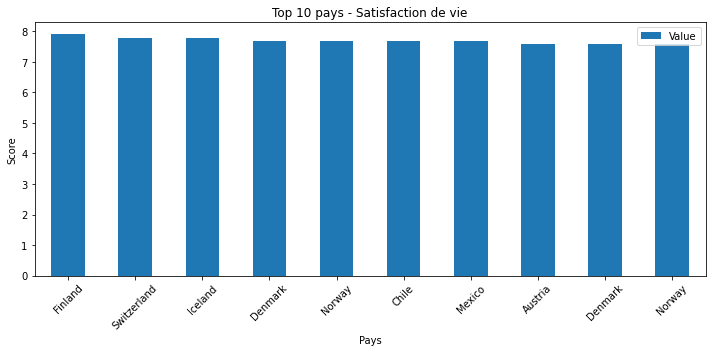

In [12]:
#VISUALISATION
top10 = life.head(10)

top10.plot(x="Country", y="Value", kind="bar", figsize=(10,5))
plt.title("Top 10 pays - Satisfaction de vie")
plt.xlabel("Pays")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

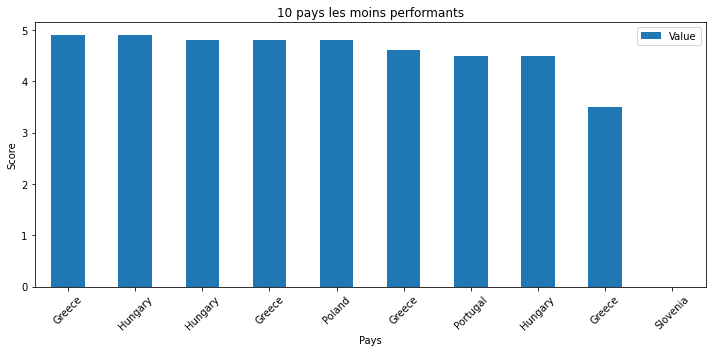

In [13]:
bottom10 = life.tail(10)

bottom10.plot(x="Country", y="Value", kind="bar", figsize=(10,5))
plt.title("10 pays les moins performants")
plt.xlabel("Pays")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

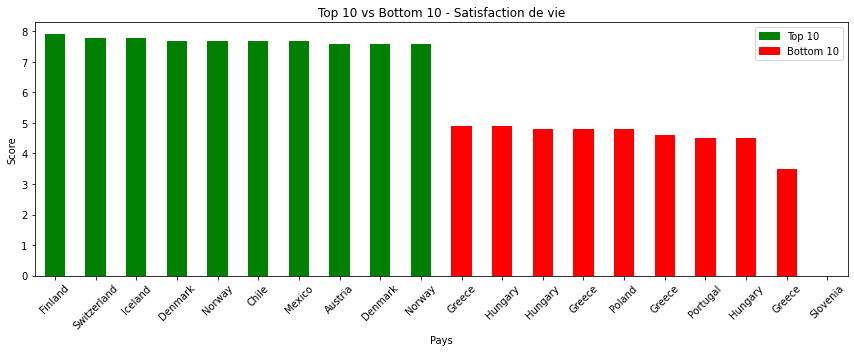

In [14]:
top10 = life.head(10)
bottom10 = life.tail(10)

combined = pd.concat([top10, bottom10])

# Création des couleurs
colors = ["green"] * 10 + ["red"] * 10

combined.plot(x="Country", y="Value", kind="bar", figsize=(12,5), color=colors)

plt.title("Top 10 vs Bottom 10 - Satisfaction de vie")
plt.xlabel("Pays")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()

import matplotlib.patches as mpatches

green_patch = mpatches.Patch(color='green', label='Top 10')
red_patch = mpatches.Patch(color='red', label='Bottom 10')

plt.legend(handles=[green_patch, red_patch])

plt.show()

In [15]:
life["Value"].mean()

6.553631284916196

## 📊 Insights

- Certains pays présentent un niveau de satisfaction de vie plus élevé
- Il existe des écarts significatifs entre les pays
- Les indicateurs socio-économiques influencent fortement la qualité de vie

## ✅ Conclusion

Cette analyse met en évidence des différences importantes entre les pays en termes de qualité de vie.

Les résultats permettent d’identifier les pays les plus performants selon certains indicateurs et fournissent une base pour des analyses plus approfondies.